In [4]:
import random
import os
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:

# 1. Cấu hình đường dẫn (Thay đổi cho đúng máy của bạn)
data_dir = r'D:\HocTap\Phân tích  và xử lý ảnh\sgu-2026-facial-expression-recognition\data\fer-2013_image\train'

# 2. Lấy danh sách tên thư mục cảm xúc (angry, disgust, fear, v.v.)
emotions = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9892\3151848157.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')


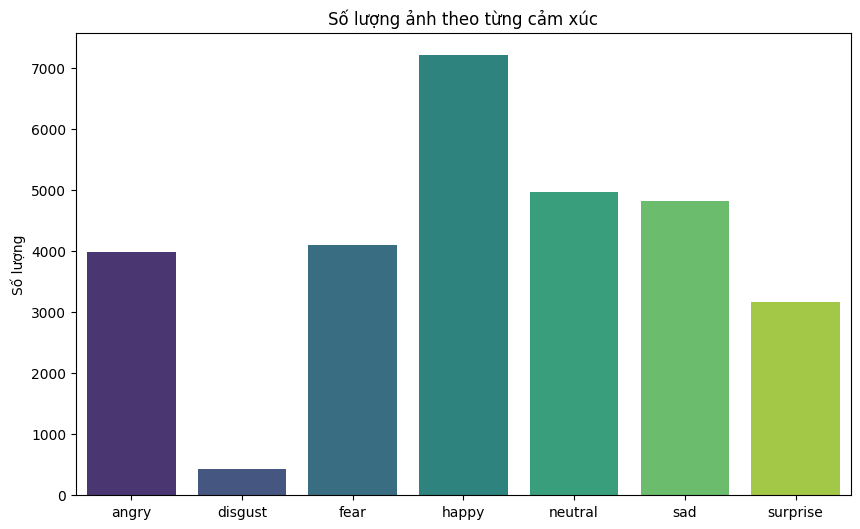

In [5]:
# Tạo list chứa số lượng ảnh mỗi thư mục
counts = {}
for mood in emotions:
    path = os.path.join(data_dir, mood)
    counts[mood] = len(os.listdir(path))

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='viridis')
plt.title('Số lượng ảnh theo từng cảm xúc')
plt.ylabel('Số lượng')
plt.show()

**Nhận xét**
1. Mất cân bằng dữ liệu nghiêm trọng (Data Imbalance)

Đây là vấn đề nổi cộm nhất. Có sự chênh lệch rất lớn giữa các lớp cảm xúc:

- Lớp chiếm ưu thế (Majority class): happy có số lượng ảnh áp đảo (hơn 7000 ảnh).

- Lớp thiểu số (Minority class): disgust cực kỳ ít (dưới 500 ảnh). 

- Các lớp còn lại như angry, fear, neutral, sad nằm ở mức trung bình (khoảng 4000 - 5000 ảnh), trong khi surprise cũng khá thấp (khoảng 3000 ảnh).

-> Hệ quả: Nếu bạn đưa thẳng dữ liệu này vào training, mô hình sẽ có xu hướng "học lệch". Nó sẽ nhận diện rất tốt cảm xúc happy nhưng dễ đoán sai hoặc bỏ qua cảm xúc disgust.

2. Thách thức cho mô hình
- Độ chính xác ảo (Accuracy paradox): Bạn có thể đạt được độ chính xác (Accuracy) cao chỉ vì mô hình đoán đúng nhiều ở lớp happy, nhưng thực tế mô hình lại hoạt động rất tệ ở các lớp khác.

-> Khó khăn cho lớp Disgust: Với số lượng quá ít (chưa tới 1/14 so với happy), mô hình rất khó để học được các đặc trưng (features) đặc trưng của sự ghê tởm.


In [6]:
# Lấy 1 ảnh bất kỳ kiểm tra shape
img_path = os.path.join(data_dir, 'angry', os.listdir(os.path.join(data_dir, 'angry'))[0])
sample_img = Image.open(img_path)
print(f"Kích thước ảnh mẫu: {sample_img.size}") # Nên là (48, 48)
print(f"Chế độ màu: {sample_img.mode}") # L là grayscale, RGB là ảnh màu

Kích thước ảnh mẫu: (48, 48)
Chế độ màu: L
